#  Прокаст

In [1]:
# system & utilities
import os
import gzip
import time
import pickle
import pytz
import warnings
warnings.filterwarnings('ignore')

# coding
from functools import wraps
import time
import copy
from copy import deepcopy
import datetime as dt
import random as random
from functools import reduce
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta
from typing import Dict, List, Optional

# data analysis and wrangling
import math
import numpy as np
import pandas as pd
import polars as pl
from scipy.stats import randint, uniform
from scipy import stats
from scipy.stats import skew, norm

# database & integrations
from clickhouse_driver import Client
import gspread
from gspread_dataframe import set_with_dataframe
from oauth2client.service_account import ServiceAccountCredentials
from google.oauth2.service_account import Credentials

# reporting & notifications
from slack_sdk import WebClient
from openpyxl import load_workbook
from openpyxl.styles import Alignment, Font
from openpyxl.utils import get_column_letter

# visualization & display
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import ipywidgets as widgets
from IPython.display import display
from itables import init_notebook_mode, show

# notebook settings
%matplotlib inline
init_notebook_mode(all_interactive=True)
pd.set_option('display.float_format', '{:.2f}'.format)

# machine learning
from sklearn.base import clone

from sklearn.pipeline import Pipeline

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

from category_encoders import TargetEncoder
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder, QuantileTransformer, OrdinalEncoder 

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV, KFold, RepeatedKFold, RandomizedSearchCV

from sklearn.linear_model import LogisticRegression, Perceptron, SGDClassifier, LinearRegression, Ridge, Lasso, ElasticNet, SGDRegressor
from sklearn.svm import SVC, SVR, LinearSVC
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier

from lightgbm import LGBMClassifier, LGBMRegressor
from xgboost import XGBClassifier, XGBRegressor
from catboost import CatBoostRegressor, CatBoostClassifier, Pool

from pathlib import Path
from scipy.stats import skew

from sklearn.metrics import (
    log_loss,
    precision_score,
    recall_score,
    accuracy_score,
    classification_report,
    f1_score,
    roc_auc_score,

    average_precision_score,
    mean_absolute_error,
    mean_absolute_percentage_error,
    r2_score,
    mean_squared_error, 
    root_mean_squared_error
)

# deep learning
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, Dataset

engine = Client(host='data-dep.owdp.tech',
                user='artem_aksenov',
                password='Nb+SESHO/m1FFr5',
                secure=True,
    )

# EDA

Провести базовый анализ, посчитать статистики и распределения (matplotlib)

In [1]:
train = pd.read_csv('datasets/train.csv')
test  = pd.read_csv('datasets/test.csv')

target = "SalePrice"
random_state = 42

NameError: name 'pd' is not defined

### 1) Статистики и преобразование фичей исходя из логики txt файла

In [4]:
dtype_counts = train.drop(columns=["Id"]).dtypes.value_counts()
print(dtype_counts)

numeric_features = train.drop(columns=["Id", target]).select_dtypes(include=[np.number]).columns.tolist()
categorical_features = train.select_dtypes(include="object").columns.tolist()
print(f"\n{len(numeric_features)} интовых, {len(categorical_features)} категориальных фичей")

str        43
int64      34
float64     3
Name: count, dtype: int64

36 интовых, 43 категориальных фичей


In [5]:
train.head()

Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


In [6]:
train.describe().T

Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


In [7]:
train.describe(include="object").T

Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


In [8]:
print("Duplicate rows in train:", train.duplicated().sum())
print("Duplicate Ids in train:", train['Id'].duplicated().sum())
print("Duplicate Ids in test:", test['Id'].duplicated().sum())

Duplicate rows in train: 0
Duplicate Ids in train: 0
Duplicate Ids in test: 0


In [9]:
num_features  = ['LotFrontage','LotArea','YearBuilt','YearRemodAdd',
                 'MasVnrArea','BsmtFinSF1','BsmtFinSF2','BsmtUnfSF',
                 'TotalBsmtSF','1stFlrSF','2ndFlrSF','LowQualFinSF',
                 'GrLivArea','BsmtFullBath','BsmtHalfBath','FullBath',
                 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr',
                 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea',
                 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch',
                 'ScreenPorch', 'PoolArea', 'OverallQual', 'OverallCond']

bool_features = ['Street', 'CentralAir']

cat_features_l10 = ['MSZoning', 'Alley', 'LotShape', 'LandContour', 
                 'Utilities','LotConfig','LandSlope','Condition1',
                 'Condition2','BldgType','HouseStyle','RoofStyle',
                 'RoofMatl','MasVnrType','Foundation','Heating',
                 'Electrical','TotRmsAbvGrd','Functional',
                 'GarageType','PavedDrive']

cat_features_m10 = ['MSSubClass','Neighborhood', 'Exterior1st', 'Exterior2nd', 'SaleType']

cat_to_int    = ['BsmtQual','BsmtCond','PoolQC','Fence', 
                 'ExterQual','ExterCond', 'HeatingQC','KitchenQual',
                 'FireplaceQu', 'GarageQual', 'GarageCond','BsmtExposure',
                 'BsmtFinType1','BsmtFinType2','GarageFinish']

dop_check = ['MiscFeature','MiscVal', 'MoSold', 'YrSold',  'SaleCondition']

df_num_features = train[num_features]

df_bool_features = train[bool_features]

df_cat_features_l10 = train[cat_features_l10]

df_cat_features_m10 = train[cat_features_m10]

df_cat_to_int = train[cat_to_int]

df_dop_check = train[dop_check]


In [10]:
df_features_final = pd.concat([train['SalePrice'], df_num_features, df_bool_features, df_cat_features_l10, df_cat_features_m10,  df_cat_to_int, df_dop_check], axis=1)

### 2) Пропущенные значения

In [11]:
missing_train = train.isnull().sum()
missing_train = missing_train[missing_train > 0].sort_values(ascending=False)
missing_pct = (missing_train / len(train) * 100).round(2)
missing_df = pd.DataFrame({"n_missing": missing_train, "pct_missing": missing_pct})
missing_df

Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


In [12]:
missing_test = test.isnull().sum()
missing_test = missing_test[missing_test > 0].sort_values(ascending=False)
print(f"{len(missing_test)} columns with missing values in test (vs {len(missing_train)} in train)")
missing_test.head(20)

33 columns with missing values in test (vs 19 in train)


Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


In [13]:
cols_missing_only_in_train = set(missing_train.index) - set(missing_test.index)
cols_missing_only_in_test = set(missing_test.index) - set(missing_train.index)
print("Missing only in train:", cols_missing_only_in_train)
print("Missing only in test:", cols_missing_only_in_test)

Missing only in train: {'Electrical'}
Missing only in test: {'Exterior2nd', 'Exterior1st', 'Functional', 'BsmtHalfBath', 'BsmtUnfSF', 'BsmtFinSF2', 'BsmtFullBath', 'GarageCars', 'MSZoning', 'Utilities', 'SaleType', 'BsmtFinSF1', 'GarageArea', 'TotalBsmtSF', 'KitchenQual'}


### 3) Изучаем таргет

In [14]:
train[target]

Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


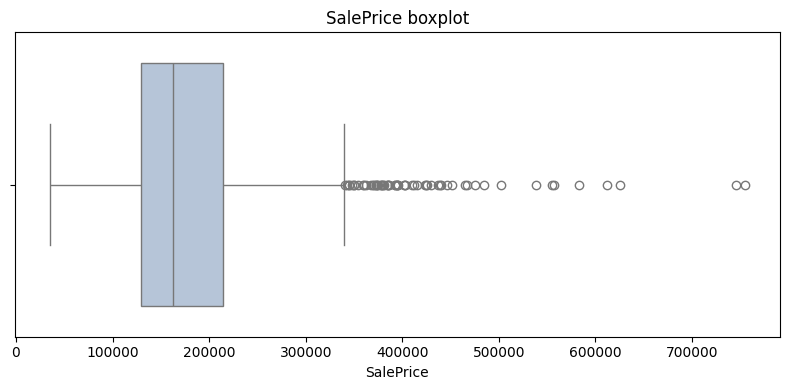

IQR 25 и 75 квантилей: [3,938, 340,038]  ->  61 потенциальные выбросы (4.2%)


In [15]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(x=train[target], ax=ax, color="lightsteelblue")
ax.set_title("SalePrice boxplot")
plt.tight_layout()
plt.show()

q1, q3 = train[target].quantile([0.25, 0.75])
iqr = q3 - q1
lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
n_outliers = ((train[target] < lower) | (train[target] > upper)).sum()
print(f"IQR 25 и 75 квантилей: [{lower:,.0f}, {upper:,.0f}]  ->  {n_outliers} потенциальные выбросы ({n_outliers/len(train)*100:.1f}%)")

In [16]:
print(train[target].describe())
print(f"\nSkewness: {train[target].skew():.3f}")
print(f"Kurtosis: {train[target].kurt():.3f}")

count     1460.00
mean    180921.20
std      79442.50
min      34900.00
25%     129975.00
50%     163000.00
75%     214000.00
max     755000.00
Name: SalePrice, dtype: float64

Skewness: 1.883
Kurtosis: 6.536


Правосторонняя асимметрия (Right Skewness = 1.883): Значение значительно больше 0. Средняя цена ($180,921) существенно выше медианной ($163,000). В датасете преобладают дома средней стоимости, но присутствуют дорогие объекты, завышающие среднее значение.

Тяжелый хвост и острый пик (Kurtosis = 6.536): Эксцесс существенно выше 3 (нормы для нормального распределения). Это указывает на наличие выбросов — нескольких сверхдорогих домов (максимум $755,000 при 75%-квантиле в $214,000).

Межквартильный размах (IQR): 50% всех домов продаются в диапазоне от $129,975 до $214,000.

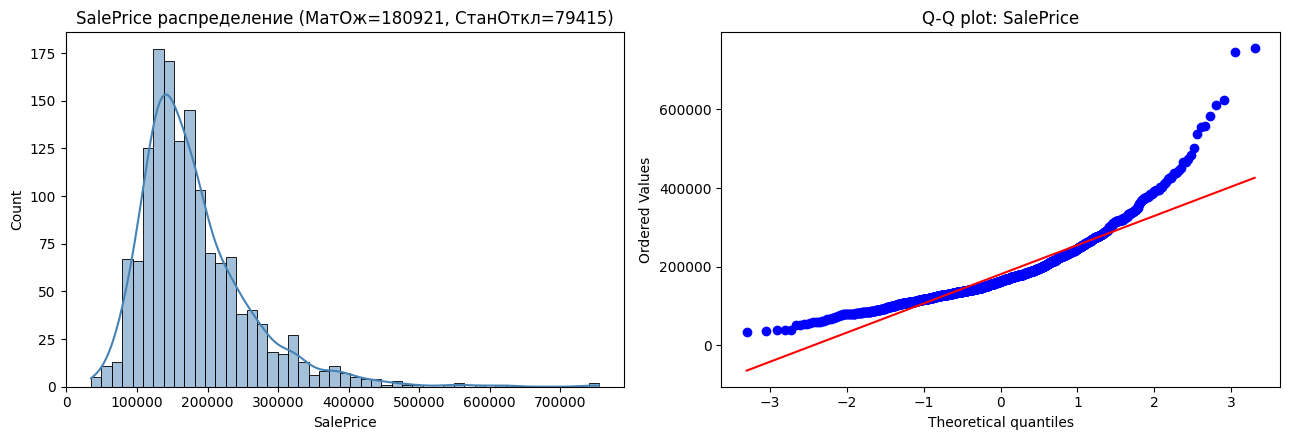

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(train[target], kde=True, ax=axes[0], color="steelblue")
(mu, sigma) = norm.fit(train[target])
axes[0].set_title(f"SalePrice распределение (МатОж={mu:.0f}, СтанОткл={sigma:.0f})")

stats.probplot(train[target], plot=axes[1])
axes[1].set_title("Q-Q plot: SalePrice")

plt.tight_layout()
plt.show()

Из-за большого количества дорогих домов, распределение имеет асимметрию, по квантиль плоту это визуализируется, т.к. если бы дисперсия была ниже, то они точки справа лежали бы рядом с линией, чтобы исправить это можно применить логарифмирование данных. 

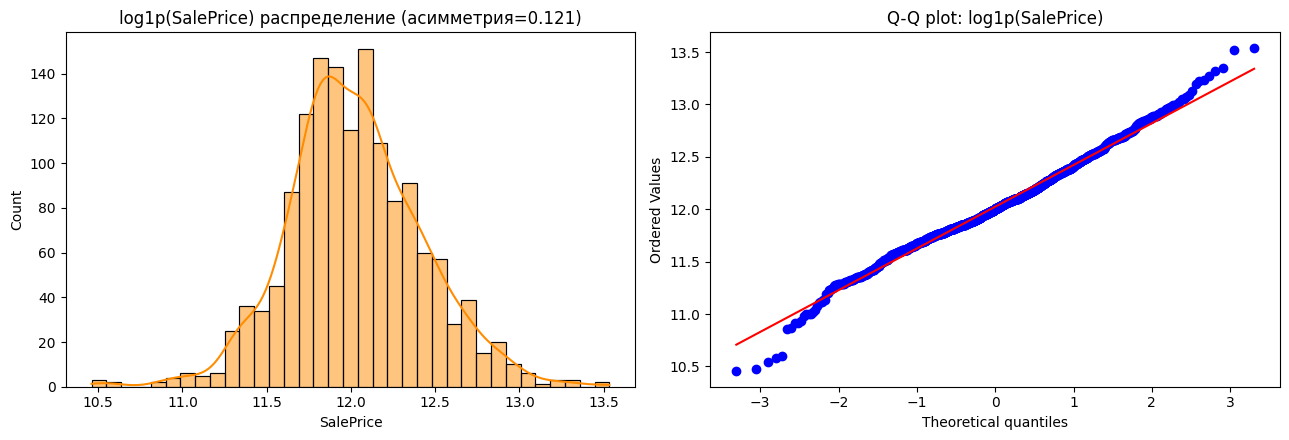

In [18]:
log_price = np.log1p(train[target])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(log_price, kde=True, ax=axes[0], color="darkorange")
axes[0].set_title(f"log1p(SalePrice) распределение (асимметрия={log_price.skew():.3f})")

stats.probplot(log_price, plot=axes[1])
axes[1].set_title("Q-Q plot: log1p(SalePrice)")

plt.tight_layout()
plt.show()

Коэфициент ассиметрии упал это видно по распределению и отношению по квантилям.

### 4) Визуализации

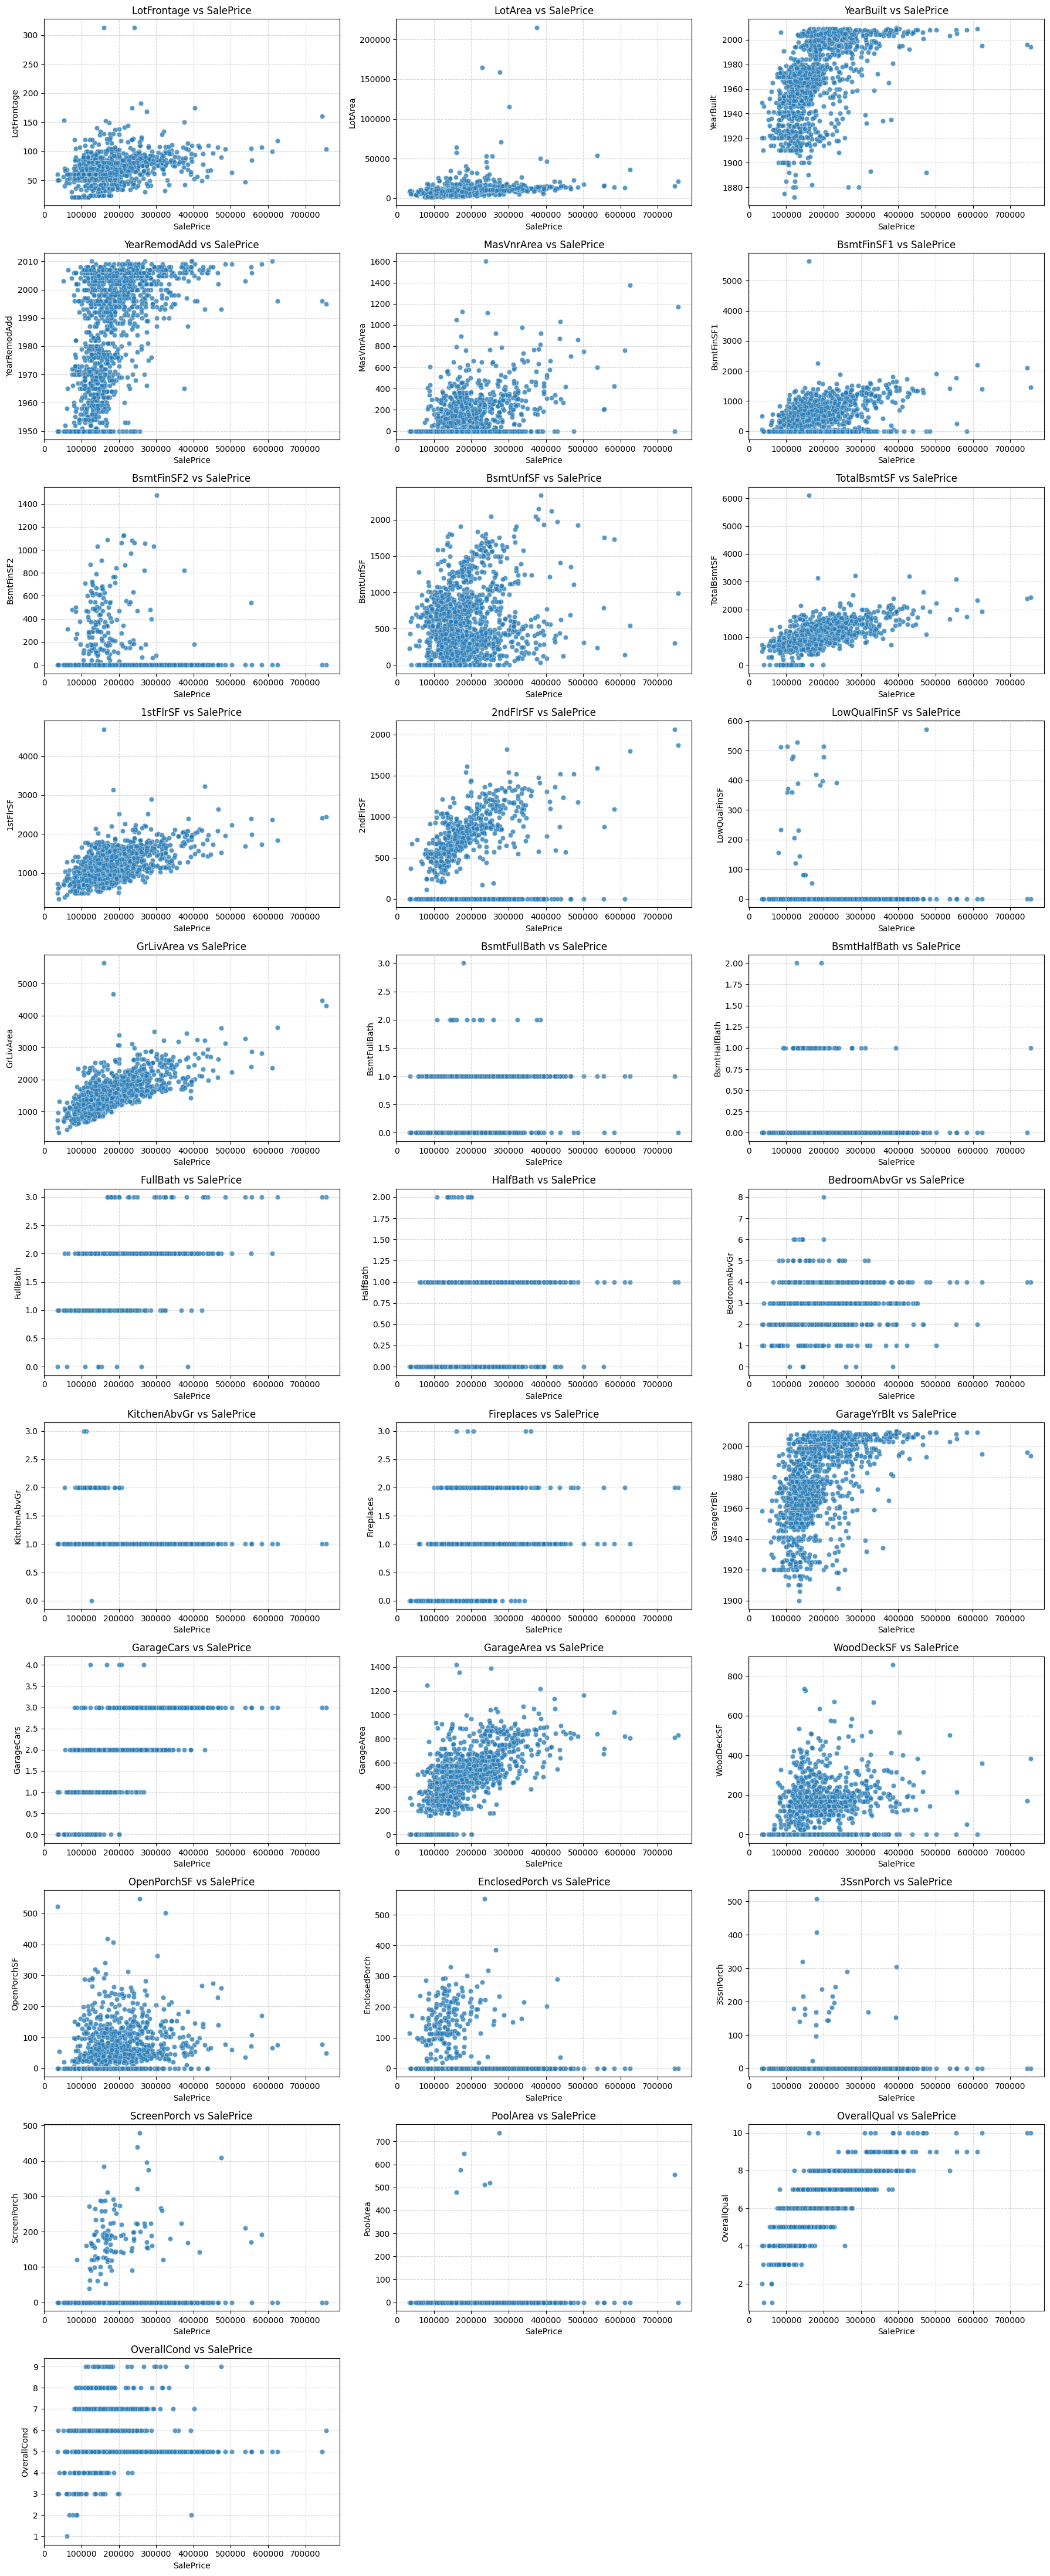

In [19]:
features = [col for col in pd.concat([train[['SalePrice']], df_num_features], axis=1).columns if col != "SalePrice"]
n_cols = 3
n_rows = math.ceil(len(features) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(features):
    # Поменяли оси: SalePrice на X, признак на Y
    sns.scatterplot(
        data=pd.concat([train[['SalePrice']], df_num_features]), x="SalePrice", y=col, ax=axes[i], alpha=0.5
    )
    axes[i].set_title(f"{col} vs SalePrice")
    axes[i].grid(True, linestyle="--", alpha=0.5)

# Скрываем пустые ячейки сетки
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

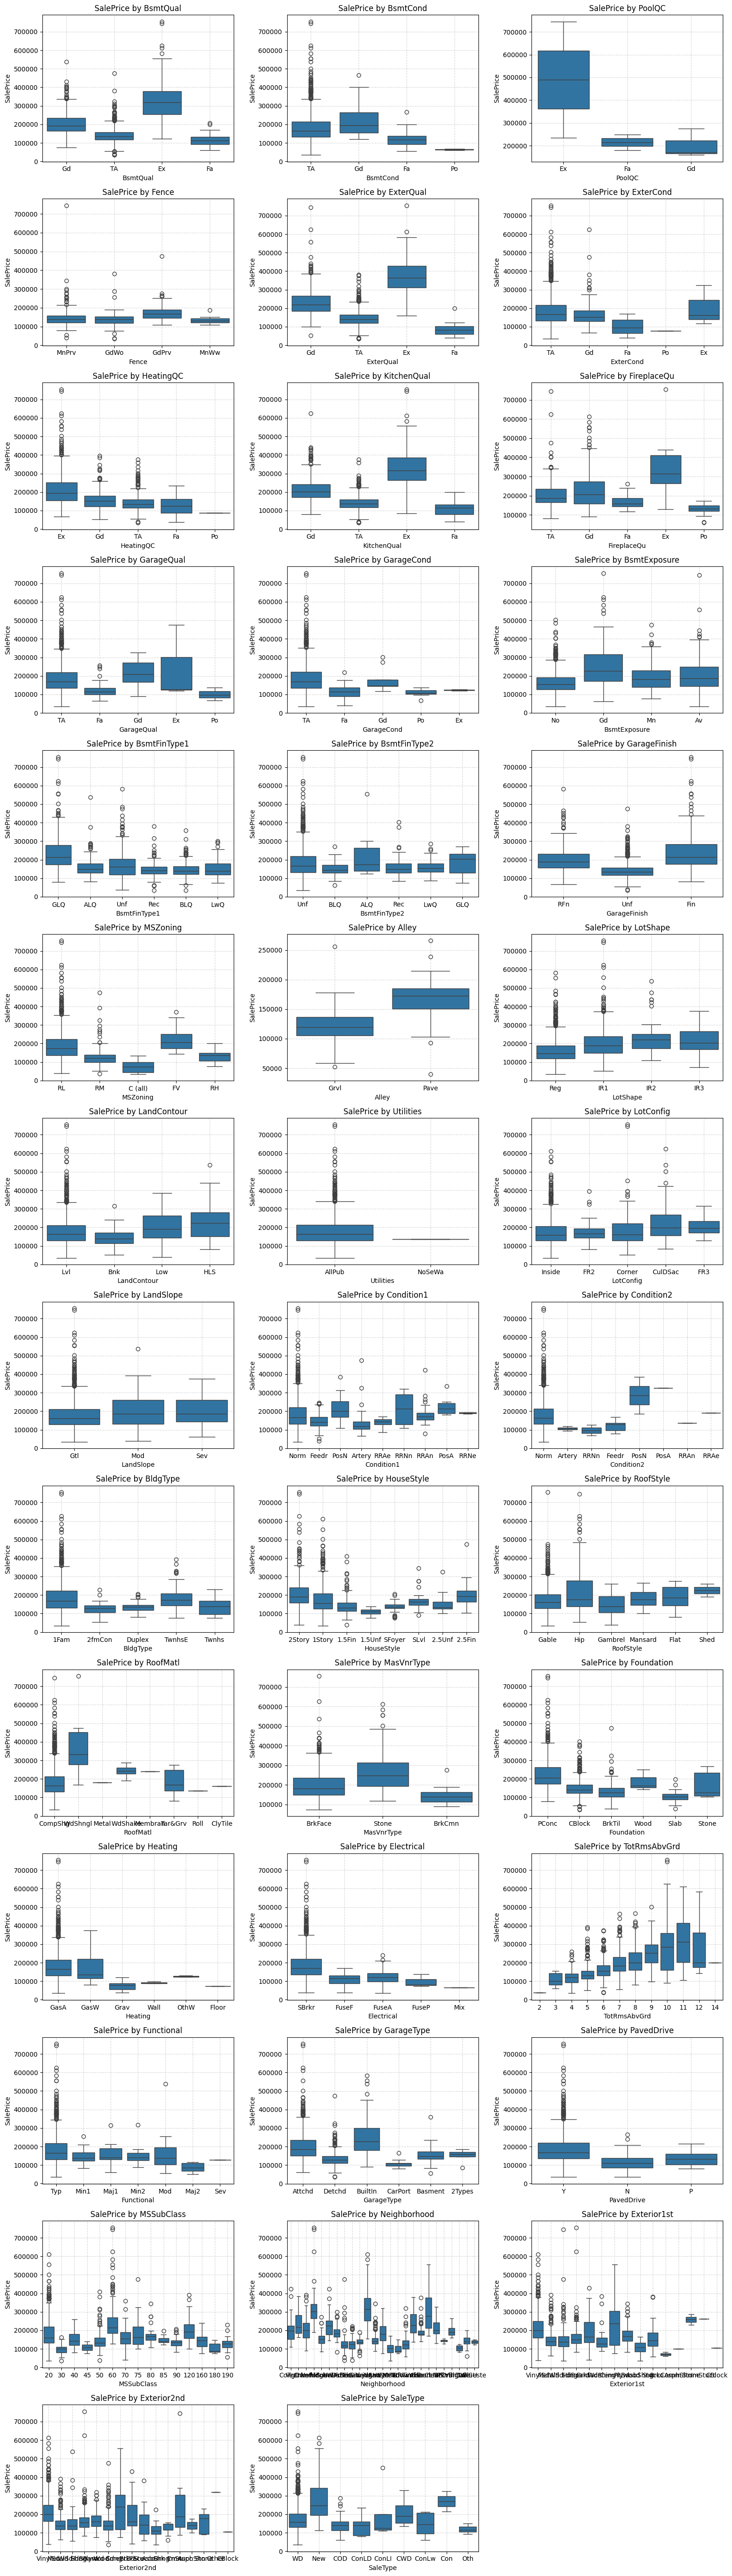

In [20]:
discrete_features = cat_to_int + cat_features_l10 + cat_features_m10
n_cols = 3
n_rows = math.ceil(len(discrete_features) / n_cols)

dataframe = pd.concat([train['SalePrice'], df_cat_features_l10, df_cat_features_m10, df_cat_to_int], axis=1)

# Динамическая высота: n_rows * 4 дюйма
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(discrete_features):
    sns.boxplot(data=dataframe, x=col, y="SalePrice", ax=axes[i])
    axes[i].set_title(f"SalePrice by {col}")
    axes[i].grid(True, linestyle="--", alpha=0.5)

# Скрываем неиспользуемые подграфики в последнем ряду
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### 5) Корреляция признаков

In [21]:
def plot_interactive_corr(
    data: pd.DataFrame, target_col: str = None, top_k: int = 100
):
    numeric_df = data.select_dtypes(include=[np.number])

    if target_col and target_col in numeric_df.columns:
        top_corrs = (
            numeric_df.corr()[target_col].abs().sort_values(ascending=False)
        )
        top_cols = top_corrs.head(top_k).index
        corr_matrix = numeric_df[top_cols].corr()
    else:
        corr_matrix = numeric_df.corr()

    fig = px.imshow(
        corr_matrix,
        text_auto=".2f",  # Округление до 2 знаков
        color_continuous_scale="RdBu_r",
        zmin=-1,
        zmax=1,
        title=f"Top {top_k} Correlation Heatmap",
    )

    # Увеличиваем размер холста
    fig.update_layout(width=1200, height=1000)
    fig.show()

plot_interactive_corr(df_num_features_final, target_col="SalePrice", top_k=100)

NameError: name 'df_num_features_final' is not defined

### 6) Разбор по районам 

In [ ]:
Neighborhood = train.groupby(['Neighborhood'], as_index=False).agg(

    SalePrice_min=('SalePrice', 'min'),
    SalePrice_max=('SalePrice', 'max'),
    SalePrice_mean=('SalePrice', 'mean'),
    total_count=('SalePrice', 'count'),

    ).sort_values(['total_count'], ascending=[False])

Neighborhood['SalePrice_mean'] = round(Neighborhood['SalePrice_mean'], 0)

Neighborhood.head(3)

Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


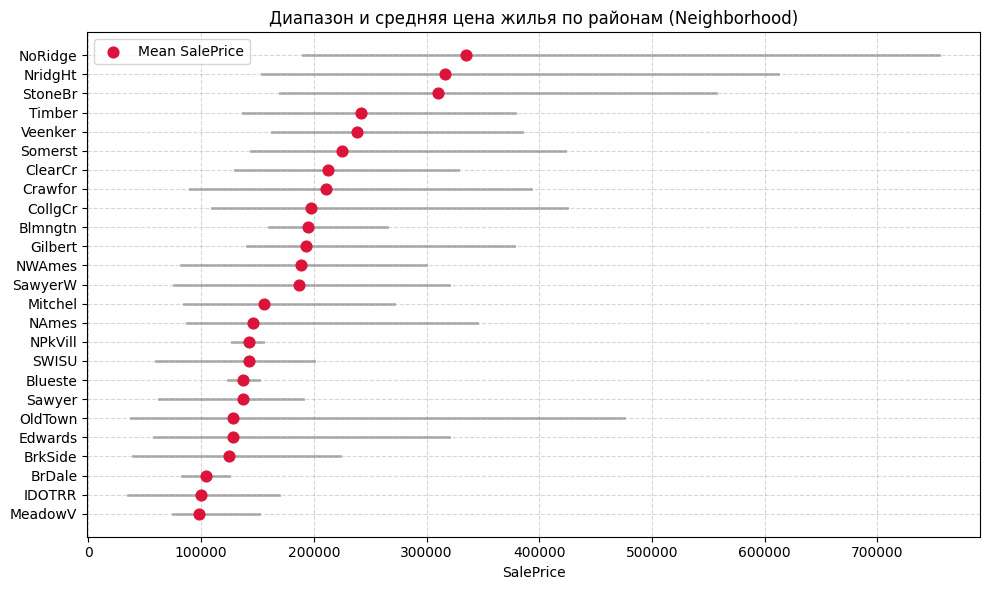

In [ ]:
# Сортируем по средней цене для наглядности
df_plot = Neighborhood.sort_values("SalePrice_mean", ascending=True)

plt.figure(figsize=(10, 6))

# Рисуем диапазон (от min до max)
for y, (_, row) in enumerate(df_plot.iterrows()):
    plt.plot(
        [row["SalePrice_min"], row["SalePrice_max"]],
        [y, y],
        color="gray",
        alpha=0.6,
        linewidth=2,
    )

# Накладываем точку средней цены
plt.scatter(
    df_plot["SalePrice_mean"],
    range(len(df_plot)),
    color="crimson",
    s=60,
    zorder=3,
    label="Mean SalePrice",
)

plt.yticks(range(len(df_plot)), df_plot["Neighborhood"])
plt.xlabel("SalePrice")
plt.title("Диапазон и средняя цена жилья по районам (Neighborhood)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

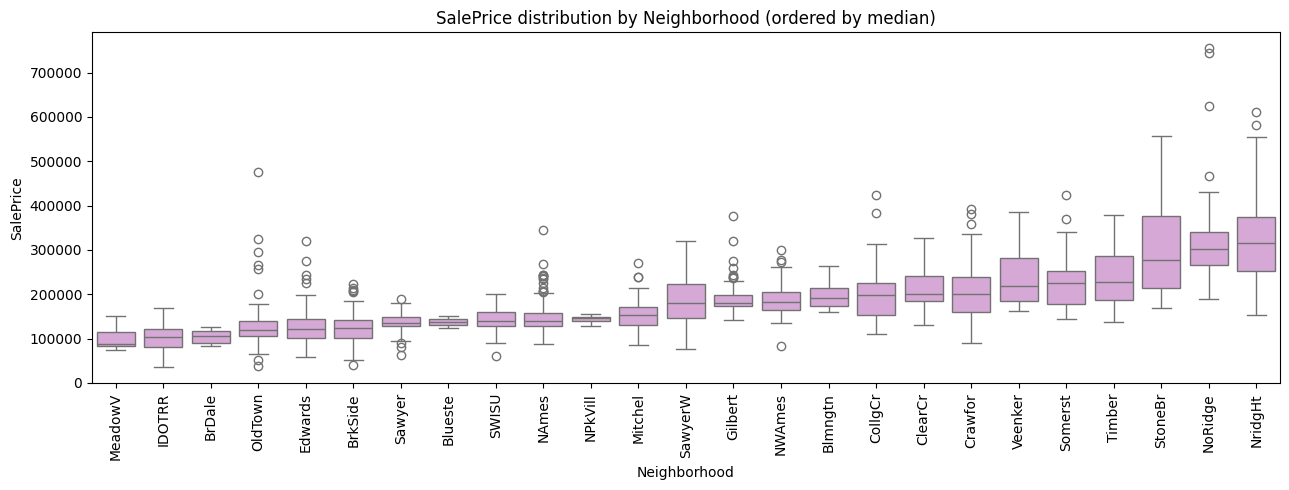

In [ ]:
order = train.groupby("Neighborhood")[target].median().sort_values().index
fig, ax = plt.subplots(figsize=(13, 5))
sns.boxplot(x="Neighborhood", y=target, data=train, order=order, ax=ax, color="plum")
ax.tick_params(axis="x", rotation=90)
ax.set_title("SalePrice distribution by Neighborhood (ordered by median)")
plt.tight_layout()
plt.show()

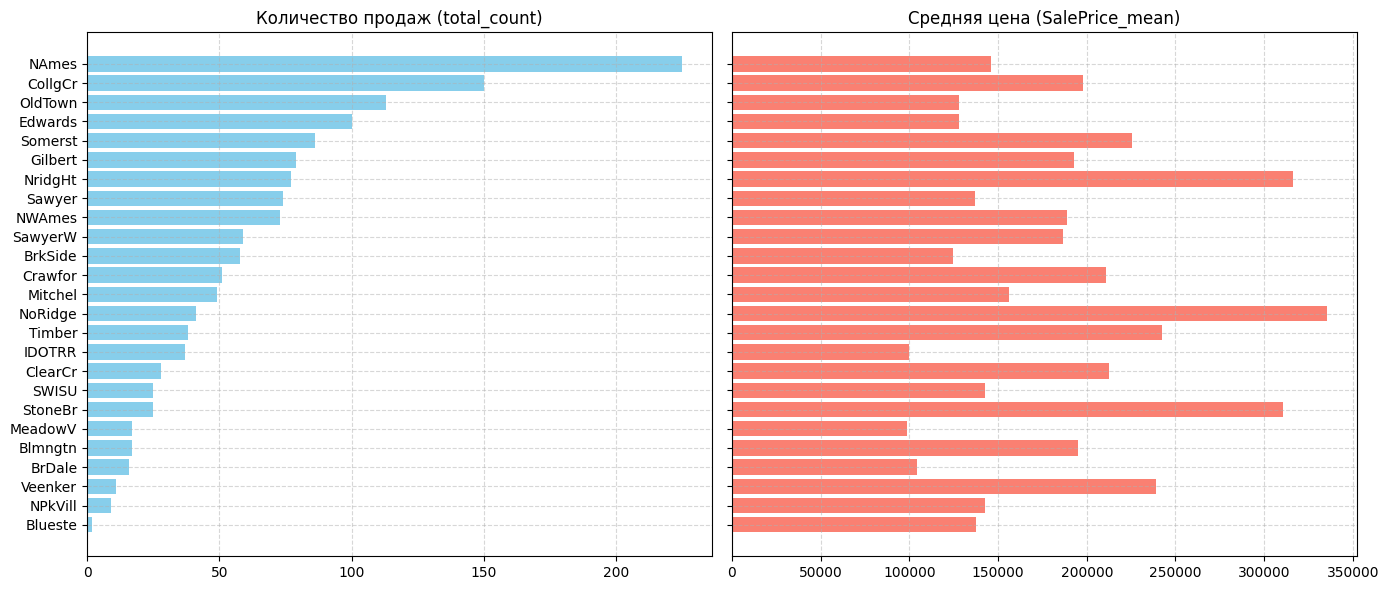

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

df_plot = Neighborhood.sort_values("total_count", ascending=True)

# 1. Объем продаж
axes[0].barh(df_plot["Neighborhood"], df_plot["total_count"], color="skyblue")
axes[0].set_title("Количество продаж (total_count)")
axes[0].grid(True, linestyle="--", alpha=0.5)

# 2. Средняя цена
axes[1].barh(
    df_plot["Neighborhood"], df_plot["SalePrice_mean"], color="salmon"
)
axes[1].set_title("Средняя цена (SalePrice_mean)")
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

### 7) Мультиколлиниарность 

In [ ]:
corr_no_target = train[numeric_features].corr().abs()
upper = corr_no_target.where(np.triu(np.ones(corr_no_target.shape), k=1).astype(bool))

pairs = (
    upper.stack()
    .reset_index()
    .rename(columns={"level_0": "feature_1", "level_1": "feature_2", 0: "abs_corr"})
    .sort_values("abs_corr", ascending=False)
)
pairs[pairs["abs_corr"] > 0.7]

Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


Удалить GarageArea, GarageYrBlt, TotRmsAbvGrd, 1stFlrSF из-за высокой мультиколлинеарности

### 8) Статистика по датам

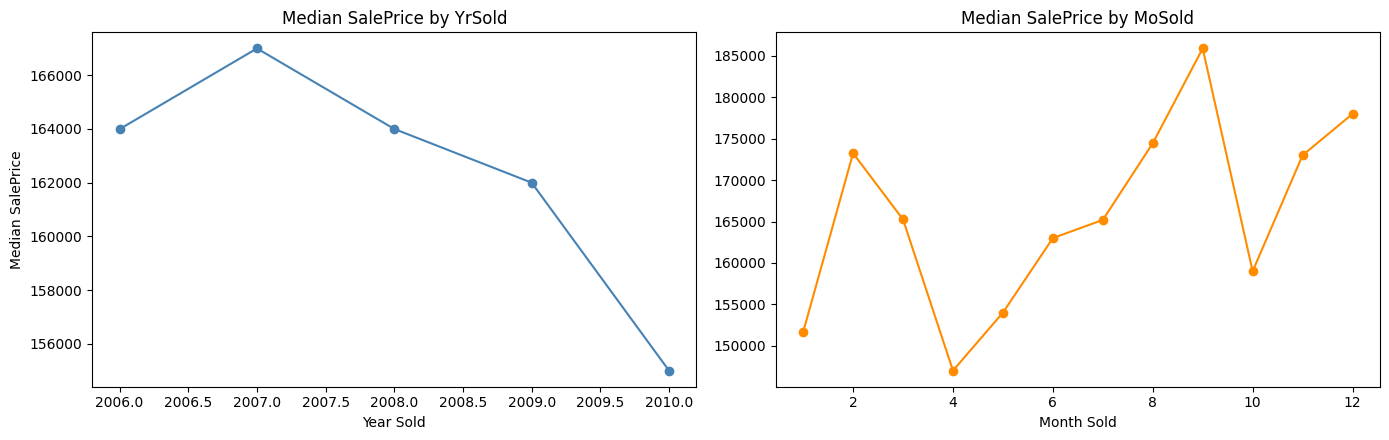

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

yearly_median = train.groupby("YrSold")[target].median()
axes[0].plot(yearly_median.index, yearly_median.values, marker="o", color="steelblue")
axes[0].set_title("Median SalePrice by YrSold")
axes[0].set_xlabel("Year Sold")
axes[0].set_ylabel("Median SalePrice")

monthly_median = train.groupby("MoSold")[target].median()
axes[1].plot(monthly_median.index, monthly_median.values, marker="o", color="darkorange")
axes[1].set_title("Median SalePrice by MoSold")
axes[1].set_xlabel("Month Sold")

plt.tight_layout()
plt.show()

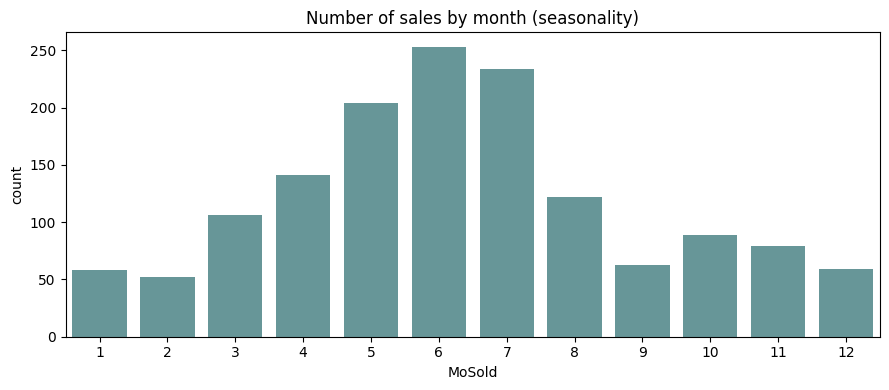

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))
sns.countplot(x="MoSold", data=train, color="cadetblue", ax=ax)
ax.set_title("Number of sales by month (seasonality)")
plt.tight_layout()
plt.show()

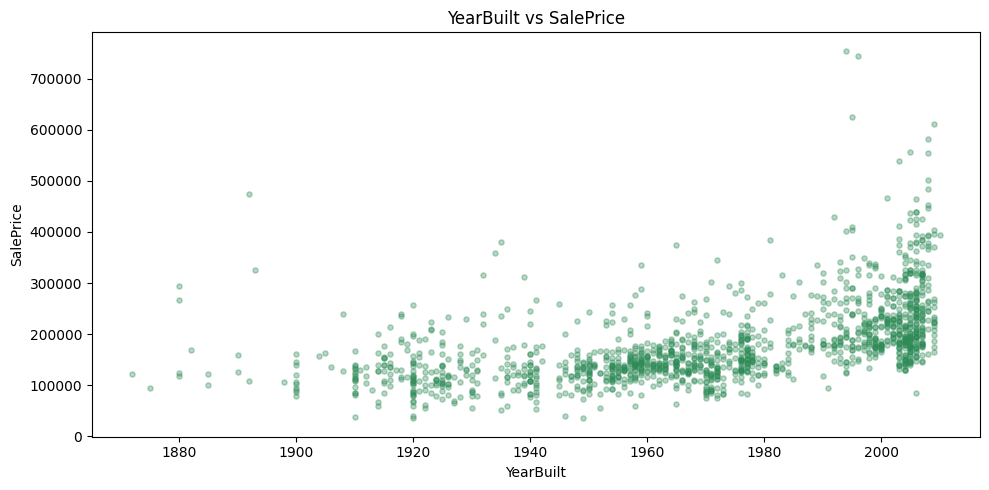

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(train["YearBuilt"], train[target], alpha=0.35, s=14, color="seagreen")
ax.set_xlabel("YearBuilt")
ax.set_ylabel("SalePrice")
ax.set_title("YearBuilt vs SalePrice")
plt.tight_layout()
plt.show()

1) Большинство домов продано в летние месяцы
2) Цена домов растет по мере роста года постройки
3) Цена продажи от месяца продажи не по графику слабо связаны

### 9

In [ ]:
explore = train.copy()

explore["TotalSF"] = explore[["TotalBsmtSF", "1stFlrSF", "2ndFlrSF"]].sum(axis=1)
explore["HouseAge"] = explore["YrSold"] - explore["YearBuilt"]
explore["YearsSinceRemodel"] = explore["YrSold"] - explore["YearRemodAdd"]
explore["TotalBath"] = (explore["FullBath"] + 0.5 * explore["HalfBath"]
                         + explore["BsmtFullBath"] + 0.5 * explore["BsmtHalfBath"])
explore["QualityLivArea"] = explore["OverallQual"] * explore["GrLivArea"]
explore["HasPool"] = (explore["PoolArea"] > 0).astype(int)
explore["Has2ndFloor"] = (explore["2ndFlrSF"] > 0).astype(int)
explore["HasGarage"] = (explore["GarageArea"] > 0).astype(int)

engineered = ["TotalSF", "HouseAge", "YearsSinceRemodel", "TotalBath", "QualityLivArea"]
eng_corr = explore[engineered + [target]].corr()[target].drop(target).sort_values(ascending=False)
print("Correlation of engineered features with SalePrice:")
print(eng_corr)

Correlation of engineered features with SalePrice:
QualityLivArea       0.83
TotalSF              0.78
TotalBath            0.63
YearsSinceRemodel   -0.51
HouseAge            -0.52
Name: SalePrice, dtype: float64


1. Создание новых фичей (Feature Generation):

TotalSF: суммируется общая площадь дома — подвал (TotalBsmtSF), первый этаж (1stFlrSF) и второй этаж (2ndFlrSF).

HouseAge: возраст дома на момент продажи (YrSold − YearBuilt).

YearsSinceRemodel: сколько лет прошло с момента ремонта или реконструкции (YrSold − YearRemodAdd).

TotalBath: общее количество ванн/санузлов. Полноценные считаются за 1, совмещенные/половинчатые (HalfBath, BsmtHalfBath) — с коэффициентом 0.5.

QualityLivArea: гибридная фича, взаимодействие общего качества и жилой площади (OverallQual * GrLivArea).

HasPool, Has2ndFloor, HasGarage: бинарные флаги (0 или 1), указывающие на наличие бассейна, второго этажа или гаража.

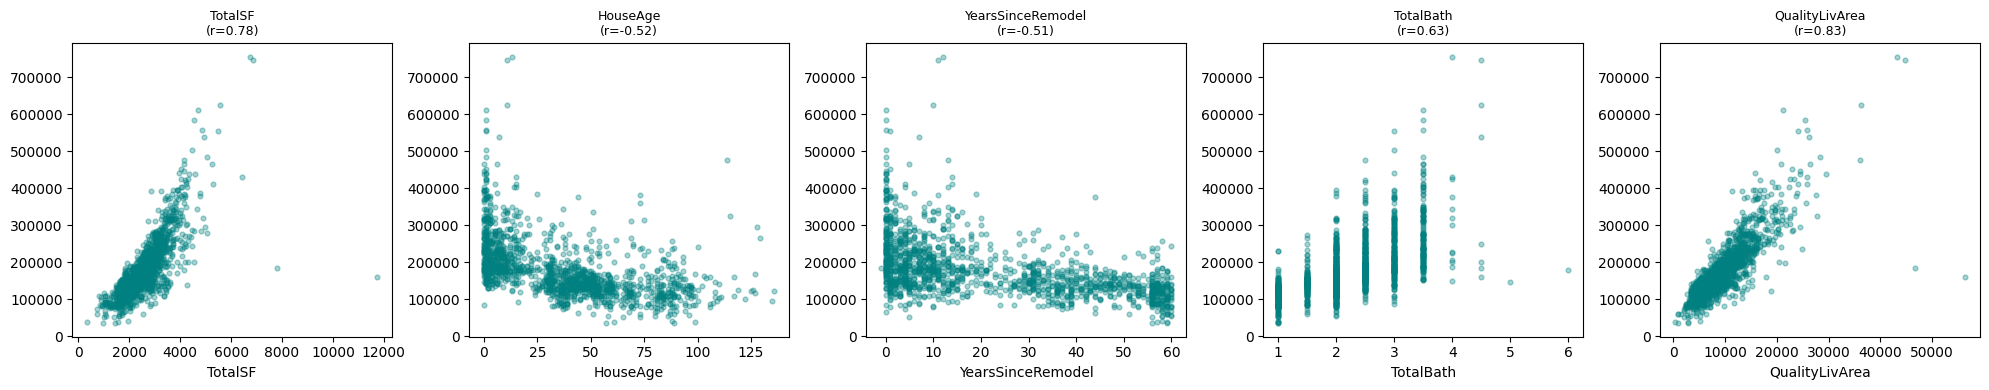

In [ ]:
fig, axes = plt.subplots(1, len(engineered), figsize=(4 * len(engineered), 4))
for ax, col in zip(axes, engineered):
    ax.scatter(explore[col], explore[target], alpha=0.35, s=12, color="teal")
    ax.set_title(f"{col}\n(r={eng_corr[col]:.2f})", fontsize=9)
    ax.set_xlabel(col)
plt.tight_layout()
plt.show()

1. Распределение целевой переменной (Target)
SalePrice имеет правое смещение (скошенность, skew ≈ 1.88).

Что делать: Применить логарифмирование (np.log1p). Это приведет распределение цен к нормальному, стабилизирует дисперсию и улучшит качество работы линейных моделей и градиентного бустинга.

2. Пропущенные значения (Missing data)
Пропуски в признаках вроде PoolQC (бассейн), Alley (переулок), Fence (забор), Garage* и Bsmt* — это не ошибки сбора данных, а отсутствие самого объекта у дома (например, "нет гаража").

Что делать: Заполнять пропуски не средним/медианой, а специальной категорией 'None' (для категориальных) или 0 (для численных).

3. Сильнейшие линейные предикторы (Strongest predictors)
Признаки с наивысшей корреляцией с ценой: общее качество (OverallQual), жилая площадь (GrLivArea), параметры гаража и подвала, а также год постройки.

Что делать: Обратить на них особое внимание при валидации и оценке валяжности фичей (Feature Importance).

4. Выбросы (Outliers)
Найдено 2 аномальных дома с жилой площадью GrLivArea > 4000 кв. футов, которые продались по необычно низкой цене (классические аномалии датасета Ames Housing).

Что делать: Удалить эти 2 наблюдения из обучающей выборки (train), чтобы они не искажали гиперплоскость или границы деревьев решений.

5. Мультиколлинеарность (Multicollinearity)
Обнаружены пары сильно коррелирующих между собой признаков (например, GarageCars и GarageArea, или TotalBsmtSF и 1stFlrSF).

Что делать: Для линейных моделей (Ridge/Lasso) стоит дропнуть один из дублирующих признаков или использовать L1/L2-регуляризацию, чтобы избежать нестабильности весов. Деревянные модели (CatBoost, LightGBM) к этому менее чувствительны.

6. Категориальные признаки (Categorical effects)
Neighborhood (район), MSZoning и SaleCondition сильно влияют на медианную стоимость.

Что делать: Район (Neighborhood) имеет много уникальных значений (высокая кардинальность), поэтому для него отлично подойдет Target Encoding или Frequency Encoding.

7. Сезонность (Seasonality)
Месяцы продаж (MoSold) имеют пик летом (май–июль), но сам месяц почти не коррелирует с итоговой ценой продажи.

Что делать: Признак можно не усложнять или оставить в исходном виде, так как явной ценовой сезонности нет.

8. Проверка сгенерированных фичей (Engineered features)
Новые гибридные фичи TotalSF и QualityLivArea показывают более высокую корреляцию с ценой, чем исходные колонки по отдельности.

# Предобработка данных

1. Исследовать и обработать пропуски в данных, если таковые имеются
2. Нормализовать данные, если потребуется
3. Проверить наличие константных и скорелированных фичей
4. Обработать категориальные фичи для моделей, которым это требуется, попробовать разные способы
5. Изучить выбросы

### Обработка

In [7]:
train = pd.read_csv('datasets/train.csv')
test  = pd.read_csv('datasets/test.csv')

target = "SalePrice"
random_state = 42

In [16]:
test_ids = test["Id"].copy()
y_train_full = train[target].copy()

train_features = train.drop(columns=[target])
n_train = train_features.shape[0]

combined = pd.concat([train_features, test], axis=0, ignore_index=True)

In [17]:
if "Functional" in combined.columns:
    combined["Functional"] = combined["Functional"].fillna("Typ")

if "Exterior2nd" in combined.columns:
    corrections = {"Wd Shng": "Wd Sdng", "CmentBd": "CemntBd", "Brk Cmn": "BrkComm"}
    combined["Exterior2nd"] = combined["Exterior2nd"].replace(corrections)

if "LotFrontage" in combined.columns and "Neighborhood" in combined.columns:
    combined["LotFrontage"] = combined.groupby("Neighborhood")["LotFrontage"].transform(
        lambda s: s.fillna(s.median())
    )

qual_map = {"Ex": 5, "Gd": 4, "TA": 3, "Fa": 2, "Po": 1, "NA": 0}
quality_cols = [
    "PoolQC", "GarageQual", "GarageCond", "BsmtQual", "BsmtCond",
    "ExterQual", "ExterCond", "KitchenQual", "HeatingQC", "FireplaceQu",
]
for col in quality_cols:
    if col in combined.columns:
        combined[col] = combined[col].map(qual_map).fillna(0).astype(int)


### Доп фичи

In [18]:
if {"TotalBsmtSF", "1stFlrSF", "2ndFlrSF"}.issubset(combined.columns):
    combined["TotalSF"] = combined["TotalBsmtSF"].fillna(0) + combined["1stFlrSF"] + combined["2ndFlrSF"]

if {"YrSold", "YearBuilt"}.issubset(combined.columns):
    combined["HouseAge"] = combined["YrSold"] - combined["YearBuilt"]

bath_cols = {"FullBath", "HalfBath", "BsmtFullBath", "BsmtHalfBath"}
if bath_cols.issubset(combined.columns):
    combined["TotalBath"] = (
        combined["FullBath"].fillna(0)
        + 0.5 * combined["HalfBath"].fillna(0)
        + combined["BsmtFullBath"].fillna(0)
        + 0.5 * combined["BsmtHalfBath"].fillna(0)
    )

if {"OverallQual", "GrLivArea"}.issubset(combined.columns):
    combined["QualityLivArea"] = combined["OverallQual"] * combined["GrLivArea"]

if {"YrSold", "YearRemodAdd"}.issubset(combined.columns):
    combined["YearsSinceRemodel"] = combined["YrSold"] - combined["YearRemodAdd"]

has_flag_specs = {
    "HasPool": "PoolArea",
    "Has2ndFloor": "2ndFlrSF",
    "HasBsmt": "TotalBsmtSF",
    "HasFireplace": "Fireplaces",
    "HasGarage": "GarageArea",
}
for flag_name, source_col in has_flag_specs.items():
    if source_col in combined.columns:
        combined[flag_name] = (combined[source_col].fillna(0) > 0).astype(int)


In [19]:
HAS_NEIGHBORHOOD = "Neighborhood" in combined.columns
if HAS_NEIGHBORHOOD:
    neighborhood_all = combined["Neighborhood"].fillna("Unknown").reset_index(drop=True)
    combined = combined.drop(columns=["Neighborhood"])
    print("Neighborhood set aside for target encoding")


Neighborhood set aside for target encoding


In [20]:
RARE_THRESHOLD = 0.01
categorical_cols = combined.select_dtypes(include="object").columns.tolist()
for col in categorical_cols:
    freq = combined[col].value_counts(normalize=True, dropna=True)
    rare_categories = freq[freq < RARE_THRESHOLD].index
    if len(rare_categories) > 0:
        combined[col] = combined[col].where(~combined[col].isin(rare_categories), "Other")
print(f"Rare-category grouping applied to {len(categorical_cols)} categorical columns")


Rare-category grouping applied to 32 categorical columns


In [21]:
numeric_cols = combined.select_dtypes(include=[np.number]).columns
categorical_cols = combined.select_dtypes(include=["object"]).columns

for col in numeric_cols:
    if combined[col].isnull().any():
        combined[col] = combined[col].fillna(combined[col].median())

for col in categorical_cols:
    if combined[col].isnull().any():
        combined[col] = combined[col].fillna("None")

print("remaining nulls:", combined.isnull().sum().sum())


remaining nulls: 0


In [22]:
SKEW_THRESHOLD = 0.75
exclude_from_skew = {"Id"} | set(has_flag_specs.keys()) | set(quality_cols)

numeric_cols = [c for c in combined.select_dtypes(include=[np.number]).columns if c not in exclude_from_skew]
skewed = combined[numeric_cols].apply(lambda s: skew(s.dropna()))
skewed_cols = skewed[skewed.abs() > SKEW_THRESHOLD].index.tolist()

print(f"Log-transforming {len(skewed_cols)} skewed numeric columns")

# keep an untransformed copy of a couple of features for the residual plots later
plot_features = combined[["GrLivArea", "OverallQual"]].copy() if {"GrLivArea", "OverallQual"}.issubset(combined.columns) else None

for col in skewed_cols:
    combined[col] = np.log1p(combined[col].clip(lower=0))


Log-transforming 24 skewed numeric columns


In [23]:
cat_cols = combined.select_dtypes(include="object").columns.tolist()
combined = pd.get_dummies(combined, columns=cat_cols, dummy_na=False)

X_train = combined.iloc[:n_train, :].drop(columns=["Id"]).reset_index(drop=True)
X_test = combined.iloc[n_train:, :].drop(columns=["Id"]).reset_index(drop=True)
X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

if HAS_NEIGHBORHOOD:
    neighborhood_train = neighborhood_all.iloc[:n_train].reset_index(drop=True)
    neighborhood_test = neighborhood_all.iloc[n_train:].reset_index(drop=True)

if plot_features is not None:
    plot_features_train = plot_features.iloc[:n_train, :].reset_index(drop=True)

y_train_log = np.log1p(y_train_full).reset_index(drop=True)

print("X_train:", X_train.shape, "X_test:", X_test.shape)


X_train: (1460, 207) X_test: (1459, 207)


In [24]:
_importance_model = XGBRegressor(
    n_estimators=300, max_depth=4, learning_rate=0.05, random_state=random_state, n_jobs=-1
)
_importance_model.fit(X_train, y_train_log)

importances = pd.Series(_importance_model.feature_importances_, index=X_train.columns)
kept_features = importances[importances > 0].index.tolist()
if len(kept_features) < X_train.shape[1] * 0.5:
    kept_features = X_train.columns.tolist()

print(f"Kept {len(kept_features)} / {X_train.shape[1]} features")
X_train = X_train[kept_features]
X_test = X_test[kept_features]


Kept 147 / 207 features


In [25]:
if HAS_NEIGHBORHOOD:
    global_mean = y_train_log.mean()
    m = 10
    stats = pd.DataFrame({"Neighborhood": neighborhood_train, "target": y_train_log})
    agg = stats.groupby("Neighborhood")["target"].agg(["mean", "count"])
    smoothed = (agg["count"] * agg["mean"] + m * global_mean) / (agg["count"] + m)

    X_train_search = X_train.copy()
    X_train_search["Neighborhood_te"] = neighborhood_train.map(smoothed).fillna(global_mean).values
else:
    X_train_search = X_train.copy()

print("X_train_search:", X_train_search.shape)


X_train_search: (1460, 148)


### Препроцессинг

# Модели ClassicML

In [7]:
train = pd.read_csv('datasets/train.csv')
test  = pd.read_csv('datasets/test.csv')

target = "SalePrice"
random_state = 42

In [5]:
from preprocessing_with_val import evaluate_pipeline_with_cv_regression, process_v1, process_v2

### Baseline

In [9]:
res_v1 = evaluate_pipeline_with_cv_regression(
    train_df=train,
    processing_func=process_v1,
    target_col="SalePrice",
    pipeline_name="V1_OHE",
)

res_v1

Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


### Бусты перебор гиперпараметров:

In [ ]:
X_train, Y_train, X_test = process_v1(train, test, target_col="SalePrice")

In [ ]:
# 1. Подготовка данных с помощью process_v1
X_train, Y_train_log, X_test = process_v1(train, test, target_col="SalePrice")

search_cv = KFold(n_splits=3, shuffle=True, random_state=random_state)
N_ITER = 10

xgb_param_dist = {
    "n_estimators": randint(300, 1200),
    "max_depth": randint(3, 7),
    "learning_rate": uniform(0.01, 0.14),
    "subsample": uniform(0.6, 0.4),
    "colsample_bytree": uniform(0.6, 0.4),
    "reg_alpha": uniform(0, 1),
    "reg_lambda": uniform(0.5, 2.5),
}

xgb_search = RandomizedSearchCV(
    XGBRegressor(random_state=random_state, n_jobs=-1),
    xgb_param_dist,
    n_iter=N_ITER,
    scoring="neg_mean_squared_error",
    cv=search_cv,
    random_state=random_state,
    n_jobs=-1,
)

# 2. Обучение и поиск лучших гиперпараметров
xgb_search.fit(X_train, Y_train_log)

xgb_best_params = xgb_search.best_params_
print("XGB best CV RMSE:", np.sqrt(-xgb_search.best_score_))
print("XGB best params:", xgb_best_params)

# -------------------------------------------------------------
# 3. Предсказание на тестовой выборке (X_test)
# -------------------------------------------------------------
# best_estimator_ автоматически использует лучшие найденные параметры
test_preds_log = xgb_search.best_estimator_.predict(X_test)

# Переводим из log1p обратно в обычные доллары ($)
test_preds = np.expm1(test_preds_log)

# -------------------------------------------------------------
# 4. Сохранение результатов в формате Kaggle
# -------------------------------------------------------------
sub = pd.read_csv("datasets/sample_submission.csv")
sub["SalePrice"] = test_preds

# Сохраняем итоговый CSV без индексов
sub.to_csv("submission_xgb.csv", index=False)

print("\nФайл 'submission_xgb.csv' успешно создан и готов к отправке!")

XGB best CV RMSE: 0.1285636301911772
XGB best params: {'colsample_bytree': np.float64(0.8270801311279966), 'learning_rate': np.float64(0.014383860943778203), 'max_depth': 4, 'n_estimators': 1029, 'reg_alpha': np.float64(0.44975413336976566), 'reg_lambda': np.float64(1.4878755900045362), 'subsample': np.float64(0.9706635463175177)}

Файл 'submission_xgb.csv' успешно создан и готов к отправке!


Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


In [79]:
lgbm_param_dist = {
    "n_estimators": randint(300, 1200),
    "max_depth": randint(3, 7),
    "learning_rate": uniform(0.01, 0.14),
    "subsample": uniform(0.6, 0.4),
    "colsample_bytree": uniform(0.6, 0.4),
    "reg_alpha": uniform(0, 1),
    "reg_lambda": uniform(0.5, 2.5),
}
lgbm_search = RandomizedSearchCV(
    LGBMRegressor(random_state=random_state, n_jobs=-1, verbosity=-1),
    lgbm_param_dist, n_iter=N_ITER, scoring="neg_mean_squared_error",
    cv=search_cv, random_state=random_state, n_jobs=-1,
)
lgbm_search.fit(X_train_search, y_train_log)
lgbm_best_params = lgbm_search.best_params_
print("LGBM best CV RMSE:", np.sqrt(-lgbm_search.best_score_))
print("LGBM best params:", lgbm_best_params)


LGBM best CV RMSE: 0.1295098801365328
LGBM best params: {'colsample_bytree': np.float64(0.8270801311279966), 'learning_rate': np.float64(0.014383860943778203), 'max_depth': 4, 'n_estimators': 1029, 'reg_alpha': np.float64(0.44975413336976566), 'reg_lambda': np.float64(1.4878755900045362), 'subsample': np.float64(0.9706635463175177)}


In [74]:
# 1. Сетка параметров для LightGBM
lgbm_param_dist = {
    "n_estimators": randint(300, 1200),
    "max_depth": randint(3, 7),
    "learning_rate": uniform(0.01, 0.14),
    "subsample": uniform(0.6, 0.4),
    "colsample_bytree": uniform(0.6, 0.4),
    "reg_alpha": uniform(0, 1),
    "reg_lambda": uniform(0.5, 2.5),
}

# 2. Инициализация и запуск RandomizedSearchCV
lgbm_search = RandomizedSearchCV(
    LGBMRegressor(random_state=random_state, n_jobs=-1, verbosity=-1),
    lgbm_param_dist,
    n_iter=N_ITER,
    scoring="neg_mean_squared_error",
    cv=search_cv,
    random_state=random_state,
    n_jobs=-1,
)

# Обучаем на X_train и Y_train_log из process_v1
lgbm_search.fit(X_train, Y_train_log)

lgbm_best_params = lgbm_search.best_params_
print("LGBM best CV RMSE:", np.sqrt(-lgbm_search.best_score_))
print("LGBM best params:", lgbm_best_params)

# -------------------------------------------------------------
# 3. Предсказание лучшей моделью LightGBM на тесте
# -------------------------------------------------------------
test_preds_log_lgbm = lgbm_search.best_estimator_.predict(X_test)

# Переводим из log1p в обычные доллары ($)
test_preds_lgbm = np.expm1(test_preds_log_lgbm)

# -------------------------------------------------------------
# 4. Сохранение файла сабмишна для Kaggle
# -------------------------------------------------------------
sub = pd.read_csv("datasets/sample_submission.csv")
sub["SalePrice"] = test_preds_lgbm
sub.to_csv("submission_lgbm.csv", index=False)

print("\nФайл 'submission_lgbm.csv' успешно создан!")
display(sub.head())

LGBM best CV RMSE: 0.1298904657835296
LGBM best params: {'colsample_bytree': np.float64(0.6063865008880857), 'learning_rate': np.float64(0.04232513558710087), 'max_depth': 6, 'n_estimators': 666, 'reg_alpha': np.float64(0.6832635188254582), 'reg_lambda': np.float64(2.024991644456552), 'subsample': np.float64(0.9332779646944658)}

Файл 'submission_lgbm.csv' успешно создан!


Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


In [ ]:
cat_param_dist = {
    "n_estimators": randint(300, 1200),
    "max_depth": randint(3, 7),
    "learning_rate": uniform(0.01, 0.14),
    "l2_leaf_reg": uniform(1, 8),
}
cat_search = RandomizedSearchCV(
    CatBoostRegressor(random_state=random_state, verbose=0),
    cat_param_dist, n_iter=N_ITER, scoring="neg_mean_squared_error",
    cv=search_cv, random_state=random_state, n_jobs=-1,
)
cat_search.fit(X_train_search, y_train_log)
cat_best_params = cat_search.best_params_
print("CatBoost best CV RMSE:", np.sqrt(-cat_search.best_score_))
print("CatBoost best params:", cat_best_params)


CatBoost best CV RMSE: 0.12443600640941842
CatBoost best params: {'l2_leaf_reg': np.float64(1.7248514762625664), 'learning_rate': np.float64(0.09657404130663222), 'max_depth': 6, 'n_estimators': 866}


In [80]:
# 1. Сетка параметров для CatBoost
cat_param_dist = {
    "n_estimators": randint(300, 1200),
    "max_depth": randint(3, 7),
    "learning_rate": uniform(0.01, 0.14),
    "l2_leaf_reg": uniform(1, 8),
}

# 2. Инициализация и запуск RandomizedSearchCV
cat_search = RandomizedSearchCV(
    CatBoostRegressor(random_state=random_state, verbose=0),
    cat_param_dist,
    n_iter=N_ITER,
    scoring="neg_mean_squared_error",
    cv=search_cv,
    random_state=random_state,
    n_jobs=-1,
)

# Обучаем на X_train и Y_train_log из process_v1
cat_search.fit(X_train, Y_train_log)

cat_best_params = cat_search.best_params_
print("CatBoost best CV RMSE:", np.sqrt(-cat_search.best_score_))
print("CatBoost best params:", cat_best_params)

# -------------------------------------------------------------
# 3. Предсказание лучшей моделью CatBoost на тесте
# -------------------------------------------------------------
test_preds_log_cat = cat_search.best_estimator_.predict(X_test)

# Переводим из log1p в обычные доллары ($)
test_preds_cat = np.expm1(test_preds_log_cat)

# -------------------------------------------------------------
# 4. Сохранение файла сабмишна для Kaggle
# -------------------------------------------------------------
sub = pd.read_csv("datasets/sample_submission.csv")
sub["SalePrice"] = test_preds_cat
sub.to_csv("submission_catboost.csv", index=False)

print("\nФайл 'submission_catboost.csv' успешно создан!")
display(sub.head())

CatBoost best CV RMSE: 0.12410995626921544
CatBoost best params: {'l2_leaf_reg': np.float64(1.184499400331326), 'learning_rate': np.float64(0.08346845243617448), 'max_depth': 5, 'n_estimators': 981}

Файл 'submission_catboost.csv' успешно создан!


Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


### Ансамбль из 5 катбустов

In [ ]:
def process_v1(train, test, target_col="SalePrice"):
    y_train_full = train[target_col].copy()
    train_features = train.drop(columns=[target_col])
    n_train = train_features.shape[0]

    combined = pd.concat([train_features, test], axis=0, ignore_index=True)

    # 1. Заполнение спецификаций и исправлений
    if "Functional" in combined.columns:
        combined["Functional"] = combined["Functional"].fillna("Typ")

    if "Exterior2nd" in combined.columns:
        corrections = {
            "Wd Shng": "Wd Sdng",
            "CmentBd": "CemntBd",
            "Brk Cmn": "BrkComm",
        }
        combined["Exterior2nd"] = combined["Exterior2nd"].replace(corrections)

    if "LotFrontage" in combined.columns and "Neighborhood" in combined.columns:
        combined["LotFrontage"] = combined.groupby("Neighborhood")[
            "LotFrontage"
        ].transform(lambda s: s.fillna(s.median()))

    # 2. Маппинг качественных признаков
    qual_map = {"Ex": 5, "Gd": 4, "TA": 3, "Fa": 2, "Po": 1, "NA": 0}
    quality_cols = [
        "PoolQC",
        "GarageQual",
        "GarageCond",
        "BsmtQual",
        "BsmtCond",
        "ExterQual",
        "ExterCond",
        "KitchenQual",
        "HeatingQC",
        "FireplaceQu",
    ]
    for col in quality_cols:
        if col in combined.columns:
            combined[col] = combined[col].map(qual_map).fillna(0).astype(int)

    # 3. Генерация новых признаков
    if {"TotalBsmtSF", "1stFlrSF", "2ndFlrSF"}.issubset(combined.columns):
        combined["TotalSF"] = (
            combined["TotalBsmtSF"].fillna(0)
            + combined["1stFlrSF"]
            + combined["2ndFlrSF"]
        )

    if {"YrSold", "YearBuilt"}.issubset(combined.columns):
        combined["HouseAge"] = combined["YrSold"] - combined["YearBuilt"]

    bath_cols = {"FullBath", "HalfBath", "BsmtFullBath", "BsmtHalfBath"}
    if bath_cols.issubset(combined.columns):
        combined["TotalBath"] = (
            combined["FullBath"].fillna(0)
            + 0.5 * combined["HalfBath"].fillna(0)
            + combined["BsmtFullBath"].fillna(0)
            + 0.5 * combined["BsmtHalfBath"].fillna(0)
        )

    if {"OverallQual", "GrLivArea"}.issubset(combined.columns):
        combined["QualityLivArea"] = (
            combined["OverallQual"] * combined["GrLivArea"]
        )

    if {"YrSold", "YearRemodAdd"}.issubset(combined.columns):
        combined["YearsSinceRemodel"] = (
            combined["YrSold"] - combined["YearRemodAdd"]
        )

    has_flag_specs = {
        "HasPool": "PoolArea",
        "Has2ndFloor": "2ndFlrSF",
        "HasBsmt": "TotalBsmtSF",
        "HasFireplace": "Fireplaces",
        "HasGarage": "GarageArea",
    }
    for flag_name, source_col in has_flag_specs.items():
        if source_col in combined.columns:
            combined[flag_name] = (
                combined[source_col].fillna(0) > 0
            ).astype(int)

    # 4. Выделение Neighborhood под безопасный Target Encoding
    HAS_NEIGHBORHOOD = "Neighborhood" in combined.columns
    if HAS_NEIGHBORHOOD:
        neighborhood_all = (
            combined["Neighborhood"].fillna("Unknown").reset_index(drop=True)
        )
        combined = combined.drop(columns=["Neighborhood"])

    # 5. Группировка редких категорий
    RARE_THRESHOLD = 0.01
    categorical_cols = combined.select_dtypes(
        include="object"
    ).columns.tolist()
    for col in categorical_cols:
        freq = combined[col].value_counts(normalize=True, dropna=True)
        rare_categories = freq[freq < RARE_THRESHOLD].index
        if len(rare_categories) > 0:
            combined[col] = combined[col].where(
                ~combined[col].isin(rare_categories), "Other"
            )

    # 6. Обработка пропусков
    numeric_cols = combined.select_dtypes(include=[np.number]).columns
    categorical_cols = combined.select_dtypes(include=["object"]).columns

    for col in numeric_cols:
        if combined[col].isnull().any():
            combined[col] = combined[col].fillna(combined[col].median())

    for col in categorical_cols:
        if combined[col].isnull().any():
            combined[col] = combined[col].fillna("None")

    # 7. Логарифмирование скошенных признаков
    SKEW_THRESHOLD = 0.75
    exclude_from_skew = (
        {"Id"} | set(has_flag_specs.keys()) | set(quality_cols)
    )

    numeric_cols = [
        c
        for c in combined.select_dtypes(include=[np.number]).columns
        if c not in exclude_from_skew
    ]
    skewed = combined[numeric_cols].apply(lambda s: skew(s.dropna()))
    skewed_cols = skewed[skewed.abs() > SKEW_THRESHOLD].index.tolist()

    for col in skewed_cols:
        combined[col] = np.log1p(combined[col].clip(lower=0))

    # 8. OHE и разделение обратно на train / val
    cat_cols = combined.select_dtypes(include="object").columns.tolist()
    combined = pd.get_dummies(combined, columns=cat_cols, dummy_na=False)

    drop_cols = ["Id"] if "Id" in combined.columns else []
    X_train = (
        combined.iloc[:n_train, :].drop(columns=drop_cols).reset_index(drop=True)
    )
    X_test = (
        combined.iloc[n_train:, :].drop(columns=drop_cols).reset_index(drop=True)
    )
    X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

    # 9. Применение Target Encoding для Neighborhood (исправлен регистр на 'Neighborhood_te')
    if HAS_NEIGHBORHOOD:
        neigh_tr = neighborhood_all.iloc[:n_train].reset_index(drop=True)
        neigh_val = neighborhood_all.iloc[n_train:].reset_index(drop=True)

        target_map = y_train_full.groupby(neigh_tr).mean()
        global_mean = y_train_full.mean()

        X_train["Neighborhood_te"] = neigh_tr.map(target_map).fillna(global_mean)
        X_test["Neighborhood_te"] = neigh_val.map(target_map).fillna(global_mean)

    # 10. Логарифмирование целевой переменной
    Y_train_log = np.log1p(y_train_full).reset_index(drop=True)

    return X_train, Y_train_log, X_test

In [81]:
X_train, Y_train_log, X_test = process_v1(train, test, target_col="SalePrice")

In [82]:
# 1. Преобразуем результаты поиска в DataFrame и сортируем по метрике (рангу)
results_df = pd.DataFrame(cat_search.cv_results_)
top5_results = results_df.sort_values("rank_test_score").head(5)

# 2. Создаем и обучаем 5 лучших моделей, параллельно выводя их CV RMSE
top5_models = []

print("--- CV RMSE для отдельных моделей ---")
for i, (idx, row) in enumerate(top5_results.iterrows(), start=1):
    params = row["params"]

    # Рассчитываем RMSE из mean_test_score (так как scoring="neg_mean_squared_error")
    model_cv_rmse = np.sqrt(-row["mean_test_score"])
    print(f"Модель {i} CV RMSE: {model_cv_rmse:.16f}")

    # Инициализируем и обучаем модель
    model = CatBoostRegressor(
        **params, random_state=random_state + len(top5_models), verbose=0
    )
    model.fit(X_train_search, y_train_log)
    top5_models.append(model)


# 3. Функция для получения предсказаний ансамбля (усреднение)
def predict_ensemble(models, X):
    preds = np.array([model.predict(X) for model in models])
    return np.mean(preds, axis=0)


# 4. Расчет CV RMSE для всего ансамбля с использованием той же схемы кросс-валидации
ensemble_cv_scores = []

for train_idx, val_idx in search_cv.split(X_train_search, y_train_log):
    X_tr, X_val = (
        X_train_search.iloc[train_idx],
        X_train_search.iloc[val_idx],
    )
    y_tr, y_val = y_train_log.iloc[train_idx], y_train_log.iloc[val_idx]

    # Обучаем копии 5 моделей на обучающей части фолда
    fold_models = []
    for m in top5_models:
        params = m.get_params()
        fold_model = CatBoostRegressor(**params)
        fold_model.fit(X_tr, y_tr)
        fold_models.append(fold_model)

    # Получаем предсказание ансамбля на валидационной части фолда
    fold_preds = predict_ensemble(fold_models, X_val)
    mse = np.mean((y_val - fold_preds) ** 2)
    ensemble_cv_scores.append(mse)

ensemble_cv_rmse = np.sqrt(np.mean(ensemble_cv_scores))

print("\n--- Итоговая метрика ансамбля ---")
print(f"CatBoost Ensemble CV RMSE: {ensemble_cv_rmse:.16f}")

# Пример использования на тестовых данных:
# ensemble_preds = predict_ensemble(top5_models, X_test_processed)

--- CV RMSE для отдельных моделей ---
Модель 1 CV RMSE: 0.1241099562692154
Модель 2 CV RMSE: 0.1242395832297952
Модель 3 CV RMSE: 0.1247771231673398
Модель 4 CV RMSE: 0.1255528508420427
Модель 5 CV RMSE: 0.1255900804161235

--- Итоговая метрика ансамбля ---
CatBoost Ensemble CV RMSE: 0.1221801623432324


In [83]:
# 1. Преобразуем результаты поиска в DataFrame и сортируем по метрике (рангу)
results_df = pd.DataFrame(cat_search.cv_results_)
top5_results = results_df.sort_values("rank_test_score").head(5)

# 2. Создаем и обучаем 5 лучших моделей на ВСЕХ обучающих данных (X_train, Y_train_log)
top5_models = []

print("--- CV RMSE для отдельных лучших моделей CatBoost ---")
for i, (idx, row) in enumerate(top5_results.iterrows(), start=1):
    params = row["params"]

    # Рассчитываем RMSE из mean_test_score (так как scoring="neg_mean_squared_error")
    model_cv_rmse = np.sqrt(-row["mean_test_score"])
    print(f"Модель {i} CV RMSE: {model_cv_rmse:.16f}")

    # Инициализируем и обучаем модель
    model = CatBoostRegressor(
        **params, random_state=random_state + len(top5_models), verbose=0
    )
    model.fit(X_train, Y_train_log)
    top5_models.append(model)


# 3. Функция для получения предсказаний ансамбля (усреднение)
def predict_ensemble(models, X):
    preds = np.array([model.predict(X) for model in models])
    return np.mean(preds, axis=0)


# 4. Расчет CV RMSE для всего ансамбля с использованием той же схемы кросс-валидации
ensemble_cv_scores = []

for train_idx, val_idx in search_cv.split(X_train, Y_train_log):
    # Приводим к numpy/iloc в зависимости от типа данных
    if isinstance(X_train, pd.DataFrame):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = Y_train_log.iloc[train_idx], Y_train_log.iloc[val_idx]
    else:
        X_tr, X_val = X_train[train_idx], X_train[val_idx]
        y_tr, y_val = Y_train_log[train_idx], Y_train_log[val_idx]

    # Обучаем копии 5 моделей на обучающей части фолда
    fold_models = []
    for m in top5_models:
        params = m.get_params()
        fold_model = CatBoostRegressor(**params)
        fold_model.fit(X_tr, y_tr)
        fold_models.append(fold_model)

    # Получаем предсказание ансамбля на валидационной части фолда
    fold_preds = predict_ensemble(fold_models, X_val)
    mse = np.mean((y_val - fold_preds) ** 2)
    ensemble_cv_scores.append(mse)

ensemble_cv_rmse = np.sqrt(np.mean(ensemble_cv_scores))

print("\n--- Итоговая метрика ансамбля ---")
print(f"CatBoost Top-5 Ensemble CV RMSE: {ensemble_cv_rmse:.16f}")

# -------------------------------------------------------------
# 5. Предсказание на тестовой выборке X_test и выгрузка файла
# -------------------------------------------------------------
# Получаем логарифмированные предсказания ансамбля
test_preds_log_cat_ensemble = predict_ensemble(top5_models, X_test)

# Переводим из log1p обратно в обычные доллары ($)
test_preds_cat_ensemble = np.expm1(test_preds_log_cat_ensemble)

# Сохраняем сабмишн для Kaggle
sub = pd.read_csv("datasets/sample_submission.csv")
sub["SalePrice"] = test_preds_cat_ensemble
sub.to_csv("submission_catboost_ensemble.csv", index=False)

print("\nФайл 'submission_catboost_ensemble.csv' успешно создан!")
display(sub.head())

--- CV RMSE для отдельных лучших моделей CatBoost ---
Модель 1 CV RMSE: 0.1241099562692154
Модель 2 CV RMSE: 0.1242395832297952
Модель 3 CV RMSE: 0.1247771231673398
Модель 4 CV RMSE: 0.1255528508420427
Модель 5 CV RMSE: 0.1255900804161235

--- Итоговая метрика ансамбля ---
CatBoost Top-5 Ensemble CV RMSE: 0.1218936465536386

Файл 'submission_catboost_ensemble.csv' успешно создан!


Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


### Бэггинг

In [ ]:
from functools import wraps
import time
import numpy as np
import pandas as pd
from catboost import CatBoostRegressor

# ==========================================
# 1. ОПРЕДЕЛЕНИЕ ДЕКОРАТОРОВ
# ==========================================


def timer(func):
    """Декоратор для замера времени работы функции."""

    @wraps(func)
    def wrapper(*args, **kwargs):
        start_time = time.time()
        print(f"\n[START] Выполняется: {func.__name__}...")
        result = func(*args, **kwargs)
        elapsed_time = time.time() - start_time
        print(f"[END] {func.__name__} завершена за {elapsed_time:.2f} сек.")
        return result

    return wrapper


def log_step(step_name="Шаг"):
    """Декоратор с параметром для визуального разделения этапов."""

    def decorator(func):
        @wraps(func)
        def wrapper(*args, **kwargs):
            print(f"\n{'='*15} {step_name.upper()} {'='*15}")
            res = func(*args, **kwargs)
            print("=" * (32 + len(step_name)))
            return res

        return wrapper

    return decorator


def validate_data(func):
    """Декоратор для проверки отсутствия NaN в обучающих данных перед фитом."""

    @wraps(func)
    def wrapper(X, y, *args, **kwargs):
        if X.isnull().any().any():
            raise ValueError(
                f"Внимание! В датасете X для {func.__name__} есть пропуски (NaN)."
            )
        return func(X, y, *args, **kwargs)

    return wrapper


# ==========================================
# 2. ПРИМЕНЕНИЕ ДЕКОРАТОРОВ К ПАЙПЛАЙНУ
# ==========================================


@timer
@log_step("Кросс-валидация и обучение Бэггинга")
def run_bagging_pipeline(
    X_train_search, y_train_log, cat_best_params, search_cv, random_state=42
):
    best_cv_rmse = np.sqrt(-cat_search.best_score_)
    print(f"CatBoost best single CV RMSE: {best_cv_rmse:.16f}")

    # Обучение основной модели бэггинга
    ensemble_models = []
    for i in range(5):
        model = CatBoostRegressor(
            **cat_best_params, random_state=random_state + i, verbose=0
        )
        model.fit(X_train_search, y_train_log)
        ensemble_models.append(model)

    def predict_ensemble(models, X):
        preds = np.array([m.predict(X) for m in models])
        return np.mean(preds, axis=0)

    # Кросс-валидация
    ensemble_cv_scores = []
    for train_idx, val_idx in search_cv.split(X_train_search, y_train_log):
        X_tr, X_val = X_train_search.iloc[train_idx], X_train_search.iloc[val_idx]
        y_tr, y_val = y_train_log.iloc[train_idx], y_train_log.iloc[val_idx]

        fold_models = []
        for i in range(5):
            fold_model = CatBoostRegressor(
                **cat_best_params, random_state=random_state + i, verbose=0
            )
            fold_model.fit(X_tr, y_tr)
            fold_models.append(fold_model)

        fold_preds = predict_ensemble(fold_models, X_val)
        mse = np.mean((y_val - fold_preds) ** 2)
        ensemble_cv_scores.append(mse)

    bagging_cv_rmse = np.sqrt(np.mean(ensemble_cv_scores))
    print(f"\nCatBoost Bagging CV RMSE:      {bagging_cv_rmse:.16f}")

    return ensemble_models, predict_ensemble


# Вызов обернутого пайплайна:
ensemble_models, predict_fn = run_bagging_pipeline(
    X_train_search, y_train_log, cat_best_params, search_cv, random_state=42
)


[START] Выполняется: run_bagging_pipeline...

=============== КРОСС-ВАЛИДАЦИЯ И ОБУЧЕНИЕ БЭГГИНГА ===============
CatBoost best single CV RMSE: 0.1244360064094184

CatBoost Bagging CV RMSE:      0.1208195255074332
[END] run_bagging_pipeline завершена за 39.08 сек.


In [84]:
from functools import wraps
import time
import numpy as np
import pandas as pd
from catboost import CatBoostRegressor

# ==========================================
# 1. ОПРЕДЕЛЕНИЕ ДЕКОРАТОРОВ
# ==========================================


def timer(func):
    """Декоратор для замера времени работы функции."""

    @wraps(func)
    def wrapper(*args, **kwargs):
        start_time = time.time()
        print(f"\n[START] Выполняется: {func.__name__}...")
        result = func(*args, **kwargs)
        elapsed_time = time.time() - start_time
        print(f"[END] {func.__name__} завершена за {elapsed_time:.2f} сек.")
        return result

    return wrapper


def log_step(step_name="Шаг"):
    """Декоратор с параметром для визуального разделения этапов."""

    def decorator(func):
        @wraps(func)
        def wrapper(*args, **kwargs):
            print(f"\n{'='*15} {step_name.upper()} {'='*15}")
            res = func(*args, **kwargs)
            print("=" * (32 + len(step_name)))
            return res

        return wrapper

    return decorator


def validate_data(func):
    """Декоратор для проверки отсутствия NaN в обучающих данных перед фитом."""

    @wraps(func)
    def wrapper(X, y, *args, **kwargs):
        # Поддержка проверки как для DataFrame, так и для numpy.ndarray
        has_nans = (
            X.isnull().any().any()
            if isinstance(X, pd.DataFrame)
            else np.isnan(X).any()
        )
        if has_nans:
            raise ValueError(
                f"Внимание! В датасете X для {func.__name__} есть пропуски (NaN)."
            )
        return func(X, y, *args, **kwargs)

    return wrapper


# ==========================================
# 2. ПРИМЕНЕНИЕ ДЕКОРАТОРОВ К ПАЙПЛАЙНУ
# ==========================================


@timer
@log_step("Кросс-валидация и обучение Бэггинга")
def run_bagging_pipeline(
    X_train, Y_train_log, cat_best_params, search_cv, random_state=42
):
    best_cv_rmse = np.sqrt(-cat_search.best_score_)
    print(f"CatBoost best single CV RMSE: {best_cv_rmse:.16f}")

    # Обучение основной модели бэггинга
    ensemble_models = []
    for i in range(5):
        model = CatBoostRegressor(
            **cat_best_params, random_state=random_state + i, verbose=0
        )
        model.fit(X_train, Y_train_log)
        ensemble_models.append(model)

    def predict_ensemble(models, X):
        preds = np.array([m.predict(X) for m in models])
        return np.mean(preds, axis=0)

    # Кросс-валидация бэггинга
    ensemble_cv_scores = []
    for train_idx, val_idx in search_cv.split(X_train, Y_train_log):
        # Безопасная индексация под DataFrame и numpy array
        if isinstance(X_train, pd.DataFrame):
            X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
            y_tr, y_val = Y_train_log.iloc[train_idx], Y_train_log.iloc[val_idx]
        else:
            X_tr, X_val = X_train[train_idx], X_train[val_idx]
            y_tr, y_val = Y_train_log[train_idx], Y_train_log[val_idx]

        fold_models = []
        for i in range(5):
            fold_model = CatBoostRegressor(
                **cat_best_params, random_state=random_state + i, verbose=0
            )
            fold_model.fit(X_tr, y_tr)
            fold_models.append(fold_model)

        fold_preds = predict_ensemble(fold_models, X_val)
        mse = np.mean((y_val - fold_preds) ** 2)
        ensemble_cv_scores.append(mse)

    bagging_cv_rmse = np.sqrt(np.mean(ensemble_cv_scores))
    print(f"\nCatBoost Bagging CV RMSE:       {bagging_cv_rmse:.16f}")

    return ensemble_models, predict_ensemble


# Вызов обернутого пайплайна с реальными данными из process_v1:
ensemble_models, predict_fn = run_bagging_pipeline(
    X_train, Y_train_log, cat_best_params, search_cv, random_state=42
)

# -------------------------------------------------------------
# 3. Предсказание на тестовой выборке X_test и выгрузка файла
# -------------------------------------------------------------
# Получаем логарифмированные предсказания ансамбля бэггинга
test_preds_log_bagging = predict_fn(ensemble_models, X_test)

# Переводим из log1p обратно в обычные доллары ($)
test_preds_bagging = np.expm1(test_preds_log_bagging)

# Сохраняем сабмишн для Kaggle
sub = pd.read_csv("datasets/sample_submission.csv")
sub["SalePrice"] = test_preds_bagging
sub.to_csv("submission_catboost_bagging.csv", index=False)

print("\nФайл 'submission_catboost_bagging.csv' успешно сохранен!")
display(sub.head())


[START] Выполняется: run_bagging_pipeline...

=============== КРОСС-ВАЛИДАЦИЯ И ОБУЧЕНИЕ БЭГГИНГА ===============
CatBoost best single CV RMSE: 0.1241099562692154

CatBoost Bagging CV RMSE:       0.1216412232431658
[END] run_bagging_pipeline завершена за 34.28 сек.

Файл 'submission_catboost_bagging.csv' успешно сохранен!


Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


# DL

In [8]:
train = pd.read_csv('datasets/train.csv')
test  = pd.read_csv('datasets/test.csv')

target = "SalePrice"
random_state = 42

In [9]:
from preprocessing_with_val import evaluate_pipeline_with_cv_regression, process_v1, process_v2

In [12]:
from dl_pipeline import DLConfig, PyTorchMLPWrapper, DLTrainer, evaluate_nn_regression_pipelines
# Уменьшаем Learning Rate, так как предсказываем log(y) (~10-13)
cfg_simple_reg = DLConfig(
    hidden_units=[64, 32],
    activation='relu',
    device='cuda' if torch.cuda.is_available() else 'cpu',
    use_batchnorm=True, # Добавлен BatchNorm для защиты от расхождения
    dropout_rates=0.1,
    optimizer_name='adam',
    lr=1e-3,
    batch_size=64,
    epochs=150,
    early_stopping=True,
    patience=25,
    use_scheduler=False,
    task='regression'
)

cfg_advanced_reg = DLConfig(
    hidden_units=[256, 128, 64, 32],
    activation='gelu',
    device='cuda' if torch.cuda.is_available() else 'cpu',
    use_batchnorm=True,
    dropout_rates=[0.2, 0.2, 0.1, 0.0],
    optimizer_name='adamw',
    weight_decay=1e-3,
    lr=1e-3,
    batch_size=64,
    epochs=150,
    early_stopping=True,
    patience=25,
    use_scheduler=True,
    scheduler_type='cosine',
    task='regression'
)


class PyTorchMLPRegressorWrapper:
    """Исправленная обертка для DLTrainer."""

    def __init__(self, config: DLConfig):
        self.config = config
        self.trainer = None

    def fit(self, X_train, y_train_log, X_val=None, y_val_log=None):
        X_tr = np.asarray(X_train.values if hasattr(X_train, 'values') else X_train, dtype=np.float32)
        y_tr = np.asarray(y_train_log.values if hasattr(y_train_log, 'values') else y_train_log, dtype=np.float32)

        X_v = np.asarray(X_val.values if hasattr(X_val, 'values') else X_val, dtype=np.float32) if X_val is not None else None
        y_v = np.asarray(y_val_log.values if hasattr(y_val_log, 'values') else y_val_log, dtype=np.float32) if y_val_log is not None else None

        self.trainer = DLTrainer(self.config)
        self.trainer.fit(
            X_train_num=X_tr, y_train=y_tr, X_val_num=X_v, y_val=y_v
        )
        return self

    def predict_log(self, X) -> np.ndarray:
        """Возвращает сырое предсказание модели в формате log(y)."""
        X_arr = np.asarray(X.values if hasattr(X, 'values') else X, dtype=np.float32)
        return self.trainer.predict(X_arr).ravel()

    def predict(self, X) -> np.ndarray:
        """Преобразует log(y) в реальные доллары."""
        preds_log = self.predict_log(X)
        
        # Если DLTrainer уже вернул числа масштаба рублей/долларов (>1000), не применяем expm1
        if np.mean(preds_log) > 100:
            return preds_log
            
        return np.expm1(preds_log)

    def score(self, X, y_true_usd, metric='r2') -> float:
        preds_usd = self.predict(X)
        y_arr = y_true_usd.values if hasattr(y_true_usd, 'values') else y_true_usd

        # Клиппируем экстремальные выбросы, если модель выдаст бешеные числа
        preds_usd = np.clip(preds_usd, 0, 1e7)

        if metric == 'r2':
            return r2_score(y_arr, preds_usd)
        elif metric == 'rmse':
            return np.sqrt(mean_squared_error(y_arr, preds_usd))
        else:
            raise ValueError(f"Неизвестная метрика: {metric}")

ImportError: cannot import name 'evaluate_nn_regression_pipelines' from 'dl_pipeline' (c:\jupyter\houses-project\dl_pipeline.py)

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import KFold


# ==========================================
# 1. ФУНКЦИЯ ДЛЯ КРОСС-ВАЛИДАЦИИ (С ИСПРАВЛЕНИЕМ СБРОСА ВЕСОВ)
# ==========================================
# def evaluate_nn_regression_pipelines(
#     df, target_col, processing_func, pipeline_name="Pipeline"
# ):
#     kf = KFold(n_splits=5, shuffle=True, random_state=42)
#     results = []

#     # Конфигурации для создания СВЕЖИХ экземпляров на каждом фолде
#     configs_dict = {
#         "Simple MLP Regressor (2-layer)": cfg_simple_reg,
#         "Advanced MLP Regressor (4-layer + Reg)": cfg_advanced_reg,
#     }

#     for name, config in configs_dict.items():
#         cv_scores_r2 = []
#         cv_scores_rmse = []

#         for train_idx, val_idx in kf.split(df):
#             fold_train = df.iloc[train_idx]
#             fold_val = df.iloc[val_idx]

#             # Предобработка внутри фолда
#             X_tr, Y_tr_log, X_val = processing_func(
#                 fold_train, fold_val, target_col=target_col
#             )
#             y_val_log = np.log1p(fold_val[target_col])

#             # Инициализируем НОВУЮ модель для каждого фолда!
#             model_wrapper = PyTorchMLPRegressorWrapper(config)

#             # Обучение
#             model_wrapper.fit(
#                 X_train=X_tr,
#                 y_train_log=Y_tr_log,
#                 X_val=X_val,
#                 y_val_log=y_val_log,
#             )

#             # Расчет метрик
#             val_r2 = model_wrapper.score(
#                 X_val, fold_val[target_col], metric="r2"
#             )
#             val_rmse = model_wrapper.score(
#                 X_val, fold_val[target_col], metric="rmse"
#             )

#             cv_scores_r2.append(val_r2)
#             cv_scores_rmse.append(val_rmse)

#         results.append(
#             {
#                 "Model": name,
#                 f"{pipeline_name}_R2": round(np.mean(cv_scores_r2), 4),
#                 f"{pipeline_name}_RMSE": round(np.mean(cv_scores_rmse), 4),
#             }
#         )

#     return (
#         pd.DataFrame(results)
#         .sort_values(by=f"{pipeline_name}_R2", ascending=False)
#         .reset_index(drop=True)
#     )


# ==========================================
# 2. ОЦЕНКА НА КРОСС-ВАЛИДАЦИИ
# ==========================================
res_nn_reg = evaluate_nn_regression_pipelines(
    df=train,
    target_col="SalePrice",
    processing_func=process_v2,
    pipeline_name="V1_OHE",
)

print("--- Результаты кросс-валидации нейросетей ---")
display(res_nn_reg)


# ==========================================
# 3. ПОДГОТОВКА ФИНАЛЬНЫХ ТЕСТОВЫХ ПРЕДСКАЗАНИЙ И ВЫГРУЗКА
# ==========================================
# Обрабатываем весь train и test через ваш пайплайн
X_train_full, Y_train_log_full, X_test_full = process_v2(
    train, test, target_col="SalePrice"
)

# Загружаем шаблон сабмишна
sample_sub = pd.read_csv("datasets/sample_submission.csv")

# Конфигурации и имена файлов сабмишна
nn_models_to_train = {
    "submission_nn_simple.csv": cfg_simple_reg,
    "submission_nn_advanced.csv": cfg_advanced_reg,
}

for filename, config in nn_models_to_train.items():
    print(f"\n--- Обучение {filename} на полном датасете ---")

    # Создаем свежую модель для финального обучения
    final_model = PyTorchMLPRegressorWrapper(config)

    # Обучаем на 100% обучающих данных (без X_val)
    final_model.fit(
        X_train=X_train_full,
        y_train_log=Y_train_log_full,
        X_val=None,
        y_val_log=None,
    )

    # Получаем предсказания в долларах (predict автоматически вызывает np.expm1)
    test_preds_usd = final_model.predict(X_test_full)

    # Клиппируем экстремальные значения для защиты от выбросов
    test_preds_usd = np.clip(test_preds_usd, a_min=0, a_max=None)

    # Сохраняем сабмишн
    sub = sample_sub.copy()
    sub["SalePrice"] = test_preds_usd
    sub.to_csv(filename, index=False)

    print(f"Файл '{filename}' успешно создан!")

--- Результаты кросс-валидации нейросетей ---


Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)



--- Обучение submission_nn_simple.csv на полном датасете ---
Файл 'submission_nn_simple.csv' успешно создан!


Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)



--- Обучение submission_nn_advanced.csv на полном датасете ---
Файл 'submission_nn_advanced.csv' успешно создан!


Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)
